In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langgraph.graph import StateGraph, END, START
from graph_state import AgentState, parser as supervisor_parser
from prompt_supervisor import get_supervisor_system_prompt
import os

In [3]:
stp = get_supervisor_system_prompt()
user_query = "Can you explain the key differences between post-trade processing for securities and commodities, including their settlement mechanisms?"

In [4]:
outparser = stp.invoke({'question': user_query})

In [5]:
print(outparser)

text='\n        You are an intelligent routing agent responsible for selecting the most appropriate node for processing user queries in a post-trade financial environment.\n        If a user query is related to Post-Trade Processing, Foreign Exchange, Commodities, or Securities, select "rag". Otherwise, determine the appropriate node:\n        LLM → If the query requires reasoning, explanation, or open-ended text generation (e.g., asking for insights, comparisons, subjective analysis, or creative content beyond factual retrieval).\n        Crawler → If real-time external data is required, fetch information from the internet using web search tools (e.g., retrieving the latest financial news, updated stock prices, or recent market trends).\n        \n        Format Instructions: The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "arra

In [6]:
os.environ['GOOGLE_API_KEY'] = os.getenv('GOOGLE_API_KEY')

In [7]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AIMessage, HumanMessage

In [8]:
model = ChatGoogleGenerativeAI(model='gemini-1.5-flash')

In [9]:
## Workflow
workflow = StateGraph(AgentState)

In [10]:
## supervisor function
def supervisor_func(state: AgentState):
    print("->Supervisor node call->")
    messages = state.get('messages', [])
    question = ''
    if (len(messages) > 0):
        question = messages[0]

    if question:
        prompt = get_supervisor_system_prompt()

        chain = prompt | model | supervisor_parser

        output = chain.invoke({'question': question})

        parsed_output = output.model_dump()

        print('##supervisor output', parsed_output)

    return {'messages': [f"{parsed_output["node_selection_type"]}"]}

In [11]:
## llm function
def llm_func(state):
    print("->LLM node call->")
    return state

In [12]:
## RAG function
def rag_func(state):
    print("->RAG node call->")
    return state

In [13]:
## web_crawler function
def web_crawler_func(state):
    print("->Crawler node call->")
    return state

In [14]:
## Router function
def router(state: AgentState):
    print("->Router node call->")
    messages = state.get('messages', [])
    latest_message = ''
    if (len(messages) > 0):
        latest_message = messages[-1]
    return 'RAG Call' if 'rag' in latest_message else 'LLM Call' if 'llm' in latest_message else 'Crawler Call'


In [15]:
## Validation function
def validation_func(state):
    print("->Validation node call->")
    return state

In [16]:
## Validation router
def validation_router(state):
    print("->Validation router node call->")
    return 'END Call'

In [17]:
workflow.add_node('supervisor', supervisor_func)
workflow.add_node('llm', llm_func)
workflow.add_node('crawler', web_crawler_func)
workflow.add_node('rag', rag_func)
workflow.add_node('validation', validation_func)

In [18]:
workflow.add_edge(START, 'supervisor')
workflow.add_conditional_edges(
    'supervisor',
    router,
    {
        'RAG Call': 'rag',
        'LLM Call': 'llm',
        'Crawler Call': 'crawler'
    }
)
workflow.add_edge('rag', 'validation')
workflow.add_edge('llm', 'validation')
workflow.add_edge('crawler', 'validation')

In [19]:
workflow.add_conditional_edges(
    'validation',
    validation_router,
    {
        'Supervisor Call': 'supervisor',
        'END Call': END
    }
)

In [20]:
app = workflow.compile()

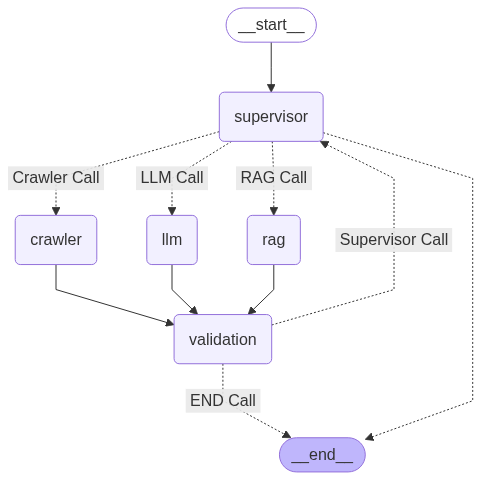

In [21]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [22]:
user_query_rag = "What are the key steps involved in the post-trade settlement process for commodities, and how does it differ from securities?"
user_query_crawler = "Find the latest commodity price trends for crude oil and gold."
user_query_llm = "Give me a creative summary of how commodities trading has evolved over the past decade."
app_state:AgentState = {'messages': [user_query_rag]} 

In [23]:
for output in app.stream(app_state):
    print('##output', output)

->Supervisor node call->
##supervisor output {'node_selection_type': 'rag'}
->Router node call->
##output {'supervisor': {'messages': ['rag']}}
->RAG node call->
##output {'rag': {'messages': ['What are the key steps involved in the post-trade settlement process for commodities, and how does it differ from securities?', 'rag']}}
->Validation node call->
->Validation router node call->
##output {'validation': {'messages': ['What are the key steps involved in the post-trade settlement process for commodities, and how does it differ from securities?', 'rag', 'What are the key steps involved in the post-trade settlement process for commodities, and how does it differ from securities?', 'rag']}}
